# Zomato Restaurants — Data Cleaning, Preprocessing & Exploratory Data Analysis

**Dataset:** `Zomato_Restaurant_Dataset.csv` — 9,551 restaurants across 15 countries (location, cuisines, cost, table booking, online delivery, rating, votes).

**Workflow**
1. Audit the raw data (types, missing values, inconsistencies, encoding damage)
2. Clean & preprocess (every step is logged)
3. Exploratory analysis & visualisation
4. Key insights and caveats

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"axes.titleweight": "bold", "axes.titlesize": 14, "axes.titlelocation": "left", "axes.labelsize": 11,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#BBBBBB",
                     "grid.color": "#EDEDED", "grid.linewidth": 0.8, "text.color": "#2B2B2B", "axes.labelcolor": "#555555",
                     "xtick.color": "#555555", "ytick.color": "#555555", "legend.frameon": False})

RED = "#E23744"          # Zomato red, used as the accent colour
DATA_PATH = "Zomato_Restaurant_Dataset.csv"
os.makedirs("charts", exist_ok=True)

def save(name):
    """Tidy the layout and keep a PNG copy of the chart in ./charts"""
    plt.tight_layout()
    plt.savefig(f"charts/{name}.png", dpi=130, bbox_inches="tight")

## 1. Load & first look

In [2]:
raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")   # the file starts with a UTF-8 BOM
print("Shape:", raw.shape)
print()
print(raw.head(3).T.to_string())

Shape: (9551, 21)

                                                                                            0                                                                    1                                                             2
Restaurant ID                                                                         6317637                                                              6304287                                                       6300002
Restaurant Name                                                              Le Petit Souffle                                                     Izakaya Kikufuji                                        Heat - Edsa Shangri-La
Country Code                                                                              162                                                                  162                                                           162
City                                                                             

## 2. Data-quality audit (before touching anything)

In [3]:
FFFD = "\ufffd"   # the Unicode "replacement character" that shows up as �
str_cols = [c for c in raw.columns if pd.api.types.is_string_dtype(raw[c])]

audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "unique": raw.nunique(),
    "corrupted_chars": [raw[c].astype(str).str.contains(FFFD, regex=False).sum() if c in str_cols else 0 for c in raw.columns],
})
print(audit.to_string())
print()
print(f"Exact duplicate rows            : {raw.duplicated().sum()}")
print(f"Duplicate Restaurant IDs        : {raw['Restaurant ID'].duplicated().sum()}")
print(f"Rating == 0 ('Not rated')       : {(raw['Aggregate rating'] == 0).sum():,}  ({(raw['Aggregate rating'] == 0).mean():.1%})")
print(f"   ...of those with votes > 0   : {((raw['Aggregate rating'] == 0) & (raw['Votes'] > 0)).sum():,}")
print(f"Average cost for two == 0       : {(raw['Average Cost for two'] == 0).sum()}")
print(f"Latitude or Longitude == 0      : {((raw['Latitude'] == 0) | (raw['Longitude'] == 0)).sum()}")
print(f"Constant columns                : {[c for c in raw.columns if raw[c].nunique() == 1]}")
print(f"Largest raw 'cost for two'      : {raw['Average Cost for two'].max():,}  (different currencies are mixed in one column)")
print()
print("Country code -> currency labels found in the file:")
print(raw.groupby("Country Code")["Currency"].agg(lambda s: " / ".join(sorted(s.unique()))).to_string())

                        dtype  missing  unique  corrupted_chars
Restaurant ID           int64        0    9551                0
Restaurant Name           str        0    7446              103
Country Code            int64        0      15                0
City                      str        0     141               54
Address                   str        0    8918               89
Locality                  str        0    1208               34
Locality Verbose          str        0    1265               66
Longitude             float64        0    8120                0
Latitude              float64        0    8677                0
Cuisines                  str        9    1825                2
Average Cost for two    int64        0     140                0
Currency                  str        0      12               80
Has Table booking         str        0       2                0
Has Online delivery       str        0       2                0
Is delivering now         str        0  

**Issues found**

| # | Issue | Where |
|---|-------|-------|
| 1 | Text damaged by a bad encoding (`�` in place of é, ã, ç, ş …) | names, cities, addresses, localities, currency |
| 2 | Country is only a numeric code | `Country Code` |
| 3 | Currency label wrong for the Philippines (`Botswana Pula`), `Dollar($)` shared by 4 countries, `Pounds(�)` corrupted | `Currency` |
| 4 | Cost is in 12 different currencies → not comparable | `Average Cost for two` |
| 5 | Cost = 0 (impossible) | `Average Cost for two` |
| 6 | Rating 0 used as "not rated", which would drag every average down | `Aggregate rating` |
| 7 | Coordinates equal to 0 / outside the stated country | `Latitude`, `Longitude` |
| 8 | 9 missing cuisines | `Cuisines` |
| 9 | Stray/double spaces | text columns |
| 10 | Constant or redundant columns | `Switch to order menu`, `Rating color` |
| 11 | Yes/No text flags | 3 columns |

## 3. Cleaning & preprocessing
Every step appends a line to a `log` so the changes can be audited at the end.

In [4]:
df = raw.copy()
log = []
def note(step, issue, action, n):
    log.append({"step": step, "issue": issue, "action": action, "affected": n})

# Step 1 — consistent snake_case column names
df.columns = (df.columns.str.strip().str.lower()
              .str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_"))
note("1", "Inconsistent column names", "Converted to snake_case", len(df.columns))
print(list(df.columns))

['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address', 'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines', 'average_cost_for_two', 'currency', 'has_table_booking', 'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu', 'price_range', 'aggregate_rating', 'rating_color', 'rating_text', 'votes']


### Step 2 — Repair the text encoding
The file already contains `�` (U+FFFD) instead of the real characters, so the original bytes cannot be recovered mechanically.
The damage is very regular though (`ã`/`é`/`ş` → two `�`, `í`/`ç`/`ö` → `�_`), so a lookup of the affected words (mostly Brazilian and Turkish place names and "Café") restores them.
Anything the lookup does not cover has its garbage characters removed, and that count is reported.

In [5]:
# '@' stands for one U+FFFD in the keys below (kept readable on purpose)
REPAIRS_RAW = {
    "Bras@_lia": "Brasília", "S@@o": "São", "S@@nia": "Sônia", "Caff@@": "Caffè", "Caf@@": "Café", "NESCAF@": "NESCAFÉ",
    "@@stanbul": "İstanbul", "@ankaya": "Çankaya", "@ukurambar": "Çukurambar", "@ayyolu": "Çayyolu", "@guas": "Águas",
    "Gaziosmanpa@@a": "Gaziosmanpaşa", "Pa@@a": "Paşa", "Be@@ikta@@": "Beşiktaş", "Beyo@@lu": "Beyoğlu",
    "Karak@_y": "Karaköy", "Macunk@_y": "Macunköy", "Kuru@_e@@me": "Kuruçeşme", "Eski@@ehir": "Eskişehir",
    "Ko@@uyolu": "Koşuyolu", "Emirg@@n": "Emirgân", "Me@@hur": "Meşhur", "Kemanke@@": "Kemankeş",
    "@@niversiteler": "Üniversiteler", "D@_ner": "Döner", "B@_ckerei": "Bäckerei", "@_mer": "Ömer",
    "Consola@_@@o": "Consolação", "Concei@_@@o": "Conceição", "Pra@_a": "Praça", "Rep@_blica": "República",
    "Apraz@_vel": "Aprazível", "Edif@_cio": "Edifício", "Terra@_o": "Terraço", "Mocot@_": "Mocotó", "Cev@_che": "Cevíche",
    "Guar@@": "Guará", "Pont@@o": "Pontão", "Metr@@": "Metrô", "G@@vea": "Gávea", "Jo@@o": "João", "Jos@@": "José",
    "Ant@@nio": "Antônio", "C@@sar": "César", "It@@lia": "Itália", "Bot@@nico": "Botânico", "Cr@@me": "Crème",
    "P@@tisserie": "Pâtisserie", "App@@tit": "Appétit", "LaBont@@": "LaBonté", "Zaz@@": "Zazá", "Bistr@@": "Bistrô",
    "Fil@@": "Filé", "pa@@a": "paşa", "Pizza @@ Bessa": "Pizza à Bessa", "Fog@@o": "Fogão", "Manzu@@": "Manzuá", "Tayp@@": "Taypá", "Pounds(@@)": "Pounds(£)",
}
REPAIRS = {k.replace("@", FFFD): v for k, v in REPAIRS_RAW.items()}
REPAIR_KEYS = sorted(REPAIRS, key=len, reverse=True)      # longest pattern first

def repair(s):
    if isinstance(s, str):
        s = s.replace("۱", "ı")                                  # Turkish dotless i, mangled into an Arabic digit
    if not isinstance(s, str) or FFFD not in s:
        return s
    for bad in REPAIR_KEYS:
        if bad in s:
            s = s.replace(bad, REPAIRS[bad])
    s = re.sub(rf"(?<=[A-Za-z]){FFFD}{{2}}s\b", "'s", s)      # It�s -> It's
    s = re.sub(rf"(?<=\d){FFFD}{{2}}(?=\d)", "°", s)          # 77�03' -> 77°03'
    s = re.sub(rf"k{FFFD}_y", "köy", s)                       # Kadıköy, Ümitköy ...
    s = re.sub(rf"(?<=\d){FFFD}{{2}}(?= Andar)", "º", s)       # 41º Andar
    s = re.sub(rf"(?<=,){FFFD}{{2}}(?=\S)", " ", s)           # non-breaking space after a comma
    s = re.sub(rf"(?<= ){FFFD}{{3}}(?= )", "–", s)             # en dash
    return s

text_cols = ["restaurant_name", "city", "address", "locality", "locality_verbose", "cuisines", "currency"]
count_bad = lambda: sum(df[c].astype(str).str.contains(FFFD, regex=False).sum() for c in text_cols)

before = count_bad()
for c in text_cols:
    df[c] = df[c].map(repair)
after_lookup = count_bad()

still = [(c, v) for c in text_cols for v in df[c].dropna().unique() if FFFD in v]
print(f"Cells with corrupted characters: {before} -> {after_lookup} after lookup repair")
print(f"{len(still)} distinct strings are still damaged (their garbage characters are removed below), e.g.:")
for c, v in still[:6]:
    print(f"   {c:16s} {v}")

for c in text_cols:                                           # fallback: drop what is left
    df[c] = df[c].map(lambda s: re.sub(rf"{FFFD}+_?", "", s) if isinstance(s, str) else s)
note("2", "Encoding damage (�)", f"Repaired {before - after_lookup} cells via lookup, stripped {after_lookup} unrecoverable cells", before)
print()
print("Cities with accents now:", sorted(c for c in df.city.unique() if re.search(r"[^\x00-\x7F]", c)))
print("Remaining corrupted cells:", count_bad())

Cells with corrupted characters: 428 -> 70 after lookup repair
60 distinct strings are still damaged (their garbage characters are removed below), e.g.:
   restaurant_name  bu��no
   restaurant_name  West��ross
   restaurant_name  Chawla's�_
   restaurant_name  Con�_u
   restaurant_name  Chhalava - �__Lava
   restaurant_name  Rosart�� Chocolate

Cities with accents now: ['Brasília', 'São Paulo', 'İstanbul']
Remaining corrupted cells: 0


### Step 3 — Whitespace, country names, currency

In [6]:
# Step 3 — stray / repeated whitespace
changed = 0
for c in text_cols:
    cleaned = df[c].str.replace(r"\s+", " ", regex=True).str.strip()
    changed += int((cleaned != df[c]).sum())
    df[c] = cleaned
note("3", "Leading/trailing/double spaces", "Collapsed and trimmed", changed)

# Step 4 — country code -> country name (standard Zomato codes)
COUNTRY = {1: "India", 14: "Australia", 30: "Brazil", 37: "Canada", 94: "Indonesia", 148: "New Zealand",
           162: "Philippines", 166: "Qatar", 184: "Singapore", 189: "South Africa", 191: "Sri Lanka",
           208: "Turkey", 214: "UAE", 215: "United Kingdom", 216: "United States"}
df["country"] = df["country_code"].map(COUNTRY)
assert df["country"].notna().all(), "unmapped country code"

# Step 5 — one reliable currency per country (the original label is wrong/ambiguous for several)
# USD per 1 unit of local currency, approximate mid-2018 levels (the period this dataset was scraped).
CURRENCY = {"India": ("INR", 0.0146), "Australia": ("AUD", 0.74), "Brazil": ("BRL", 0.27), "Canada": ("CAD", 0.77),
            "Indonesia": ("IDR", 0.00007), "New Zealand": ("NZD", 0.68), "Philippines": ("PHP", 0.019),
            "Qatar": ("QAR", 0.275), "Singapore": ("SGD", 0.74), "South Africa": ("ZAR", 0.075),
            "Sri Lanka": ("LKR", 0.0063), "Turkey": ("TRY", 0.21), "UAE": ("AED", 0.272),
            "United Kingdom": ("GBP", 1.33), "United States": ("USD", 1.0)}
df["currency_code"] = df["country"].map(lambda c: CURRENCY[c][0])
n_ph = int(((df["country"] == "Philippines") & df["currency"].str.contains("Botswana")).sum())
note("4-5", "Country only numeric; wrong / ambiguous currency labels", f"Added `country`, `currency_code` (fixed {n_ph} Philippine rows labelled Botswana Pula)", len(df))
df = df.drop(columns="currency")
print(df.groupby("country")["currency_code"].first().to_string())

country
Australia         AUD
Brazil            BRL
Canada            CAD
India             INR
Indonesia         IDR
New Zealand       NZD
Philippines       PHP
Qatar             QAR
Singapore         SGD
South Africa      ZAR
Sri Lanka         LKR
Turkey            TRY
UAE               AED
United Kingdom    GBP
United States     USD


### Step 6 — Ratings, votes, flags, redundant columns

In [7]:
# Step 6 — rating 0 means "not rated": keep a flag and use NaN so averages are not polluted
df["is_rated"] = df["aggregate_rating"] > 0
df["rating"] = df["aggregate_rating"].where(df["is_rated"])
note("6", "Rating 0 = not rated (2,148 rows)", "Added `is_rated`; `rating` is NaN when not rated", int((~df.is_rated).sum()))
print(f"Unrated restaurants that still have votes: {((~df.is_rated) & (df.votes > 0)).sum()} (kept, flagged as an anomaly of the source)")
print(f"Rated restaurants with 0 votes            : {(df.is_rated & (df.votes == 0)).sum()}")

# Step 7 — Yes/No -> 1/0
for c in ["has_table_booking", "has_online_delivery", "is_delivering_now"]:
    df[c] = df[c].map({"Yes": 1, "No": 0}).astype("int8")
note("7", "Yes/No text flags", "Converted to 1/0", 3 * len(df))

# Step 8 — drop constant / redundant columns
assert (df.groupby("rating_text")["rating_color"].nunique() == 1).all()   # colour is a 1-to-1 copy of the text
df = df.drop(columns=["switch_to_order_menu", "rating_color", "aggregate_rating"])
note("8", "Constant column (`switch_to_order_menu`), duplicate of `rating_text` (`rating_color`), `aggregate_rating` (replaced by `rating`)", "Dropped", 3)

Unrated restaurants that still have votes: 1054 (kept, flagged as an anomaly of the source)
Rated restaurants with 0 votes            : 0


### Step 9 — Cost: invalid zeros and one common currency

In [8]:
zero_cost = df["average_cost_for_two"] == 0
print(f"Rows with cost 0: {zero_cost.sum()}  -> set to NaN (a restaurant can't be free)")
df.loc[zero_cost, "average_cost_for_two"] = np.nan
note("9a", "Average cost for two = 0", "Set to NaN", int(zero_cost.sum()))

rate = df["country"].map(lambda c: CURRENCY[c][1])
df["cost_for_two_usd"] = (df["average_cost_for_two"] * rate).round(2)
df["cost_per_person_usd"] = (df["cost_for_two_usd"] / 2).round(2)
note("9b", "Costs in 12 currencies", "Added approximate USD columns (fixed ~2018 rates)", len(df))

print("\nMost expensive by cost for two (USD):")
print(df.nlargest(8, "cost_for_two_usd")[["restaurant_name", "city", "average_cost_for_two", "currency_code", "cost_for_two_usd"]].to_string())
print("\nCost per person (USD) by country — sanity check of the conversion:")
print(df.groupby("country")["cost_per_person_usd"].agg(["count", "median", "max"]).round(1).to_string())

Rows with cost 0: 18  -> set to NaN (a restaurant can't be free)

Most expensive by cost for two (USD):
                              restaurant_name        city  average_cost_for_two currency_code  cost_for_two_usd
458                          Restaurant Andre   Singapore                 500.0           SGD            370.00
460                                      Jaan   Singapore                 430.0           SGD            318.20
9384                 Restaurant Gordon Ramsay      London                 230.0           GBP            305.90
9484           Restaurant Mosaic @ The Orient    Pretoria                3210.0           ZAR            240.75
461                     Rhubarb Le Restaurant   Singapore                 315.0           SGD            233.10
456                                 Sky On 57   Singapore                 300.0           SGD            222.00
469                           Summer Pavilion   Singapore                 300.0           SGD            222.00


### Step 10 — Coordinates
Points are checked against a rough bounding box of the country they belong to. `(0, 0)` and points outside the box are treated as missing.

In [9]:
BBOX = {  # lat_min, lat_max, lon_min, lon_max
    "India": (6, 37.5, 68, 98), "Australia": (-44, -10, 112, 154.5), "Brazil": (-34, 5.5, -74, -34), "Canada": (41, 84, -141, -52),
    "Indonesia": (-11.5, 6, 95, 141.5), "New Zealand": (-47.5, -34, 166, 179), "Philippines": (4.5, 21.5, 116, 127),
    "Qatar": (24.4, 26.3, 50.7, 51.7), "Singapore": (1.1, 1.5, 103.5, 104.1), "South Africa": (-35, -22, 16, 33),
    "Sri Lanka": (5.8, 10, 79.5, 82), "Turkey": (35.8, 42.2, 25.6, 44.9), "UAE": (22.5, 26.2, 51.5, 56.5),
    "United Kingdom": (49.8, 60.9, -8.7, 1.8), "United States": (18.5, 71.5, -179.5, -66)}
box = df["country"].map(BBOX)
inside = pd.Series([b[0] <= la <= b[1] and b[2] <= lo <= b[3] for b, la, lo in zip(box, df.latitude, df.longitude)], index=df.index)
zero_xy = (df.latitude == 0) | (df.longitude == 0)
df["coords_valid"] = inside & ~zero_xy
print(f"lat/lon == 0            : {zero_xy.sum()}")
print(f"outside country bounds  : {(~inside & ~zero_xy).sum()}")
print(f"valid coordinates       : {df.coords_valid.sum():,} / {len(df):,}")
print(pd.crosstab(df.country, df.coords_valid).loc[lambda t: t[False] > 0].to_string())
df.loc[~df.coords_valid, ["latitude", "longitude"]] = np.nan
note("10", "Coordinates = 0 or outside the country", "Set lat/lon to NaN, kept `coords_valid`", int((~df.coords_valid).sum()))

lat/lon == 0            : 499
outside country bounds  : 1
valid coordinates       : 9,051 / 9,551
coords_valid  False  True 
country                   
India           497   8155
Indonesia         1     20
New Zealand       1     39
Sri Lanka         1     19


### Step 11 — Cuisines, duplicates, derived features

In [10]:
# Step 11 — cuisines: fill missing, split the comma separated list, count
print("Missing cuisines:", df.cuisines.isna().sum())
df["cuisines"] = df["cuisines"].fillna("Unknown")
note("11a", "Missing cuisines", "Filled with 'Unknown'", int((df.cuisines == "Unknown").sum()))

def to_list(s):
    out = []
    for x in s.split(","):
        x = x.strip()
        if x and x not in out:
            out.append(x)
    return out
df["cuisine_list"] = df["cuisines"].map(to_list)
df["n_cuisines"] = np.where(df["cuisines"] == "Unknown", 0, df["cuisine_list"].map(len))
df["primary_cuisine"] = df["cuisine_list"].str[0]

names = pd.Series([x for l in df.cuisine_list for x in l])
variants = names.groupby(names.str.casefold()).nunique()
print(f"Distinct cuisines: {names.nunique()}  |  spelling/case variants of the same cuisine: {(variants > 1).sum()}")

# Step 12 — duplicate listings (same name + address + locality); keep the entry with most votes
key = ["restaurant_name", "address", "locality"]
n_dup = int(df.duplicated(key).sum())
df = df.sort_values("votes", ascending=False).drop_duplicates(key, keep="first").sort_index()
note("12", "Same restaurant listed twice (name+address+locality)", "Checked — none found" if n_dup == 0 else "Dropped duplicates, kept the one with most votes", n_dup)
print(f"Duplicate listings removed: {n_dup}   ->  {len(df):,} rows remain")

# Step 13 — helpful derived columns
df["price_tier"] = df["price_range"].map({1: "Budget", 2: "Moderate", 3: "Upscale", 4: "Fine dining"})
df["delhi_ncr"] = df["city"].isin(["New Delhi", "Gurgaon", "Noida", "Faridabad", "Ghaziabad"])
df["log_votes"] = np.log10(df["votes"].clip(lower=1))
note("13", "Feature engineering", "Added price_tier, delhi_ncr, n_cuisines, primary_cuisine, log_votes", 5)

Missing cuisines: 9
Distinct cuisines: 146  |  spelling/case variants of the same cuisine: 0
Duplicate listings removed: 0   ->  9,551 rows remain


### Validation & export

In [11]:
assert df["restaurant_id"].is_unique
assert df["rating"].dropna().between(1, 5).all()
assert df["votes"].ge(0).all()
assert df["cost_for_two_usd"].dropna().gt(0).all()
assert not any(df[c].astype(str).str.contains(FFFD, regex=False).any() for c in text_cols if c in df.columns)

cleaned = df.drop(columns="cuisine_list")
cleaned.to_csv("Zomato_cleaned.csv", index=False)

print(f"Raw     : {raw.shape[0]:,} rows x {raw.shape[1]} cols")
print(f"Cleaned : {cleaned.shape[0]:,} rows x {cleaned.shape[1]} cols   ->  saved to Zomato_cleaned.csv")
print()
print("Missing values left (by design):")
print(cleaned.isna().sum().loc[lambda s: s > 0].to_string())
print()
print(pd.DataFrame(log).to_string(index=False))

Raw     : 9,551 rows x 21 cols
Cleaned : 9,551 rows x 29 cols   ->  saved to Zomato_cleaned.csv

Missing values left (by design):
longitude                500
latitude                 500
average_cost_for_two      18
rating                  2148
cost_for_two_usd          18
cost_per_person_usd       18

step                                                                                                                            issue                                                                             action  affected
   1                                                                                                        Inconsistent column names                                                            Converted to snake_case        21
   2                                                                                                              Encoding damage (�)                     Repaired 358 cells via lookup, stripped 70 unrecoverable cells       428
   3          

## 4. Exploratory Data Analysis
Unless stated otherwise, rating analyses use **rated restaurants only** (`is_rated == True`); the unrated ones are analysed separately.
Some rating axes are zoomed in (not starting at 0) so differences are visible — the values are annotated or the chart uses points/lines rather than bars.

In [12]:
rated = df[df.is_rated].copy()
print(f"Restaurants: {len(df):,} | rated: {len(rated):,} ({len(rated)/len(df):.1%}) | countries: {df.country.nunique()} | cities: {df.city.nunique()}")
print(f"India share: {(df.country == 'India').mean():.1%} | Delhi NCR share: {df.delhi_ncr.mean():.1%}")
print()
print(df[["rating", "votes", "average_cost_for_two", "cost_per_person_usd", "price_range", "n_cuisines"]].describe().round(2).T.to_string())

Restaurants: 9,551 | rated: 7,403 (77.5%) | countries: 15 | cities: 141
India share: 90.6% | Delhi NCR share: 83.2%

                       count     mean       std   min     25%     50%     75%       max
rating                7403.0     3.44      0.55  1.80    3.00    3.40    3.80       4.9
votes                 9551.0   156.91    430.17  0.00    5.00   31.00  131.00   10934.0
average_cost_for_two  9533.0  1201.48  16136.31  7.00  250.00  400.00  700.00  800000.0
cost_per_person_usd   9533.0     5.77      7.59  0.36    2.19    3.65    5.84     185.0
price_range           9551.0     1.80      0.91  1.00    1.00    2.00    2.00       4.0
n_cuisines            9551.0     2.06      1.09  0.00    1.00    2.00    3.00       8.0


### 4.1 Where are the restaurants?

country
India             8652
United States      434
United Kingdom      80
Brazil              60
UAE                 60
South Africa        60
New Zealand         40
Turkey              34
Australia           24
Philippines         22
Indonesia           21
Singapore           20
Qatar               20
Sri Lanka           20
Canada               4


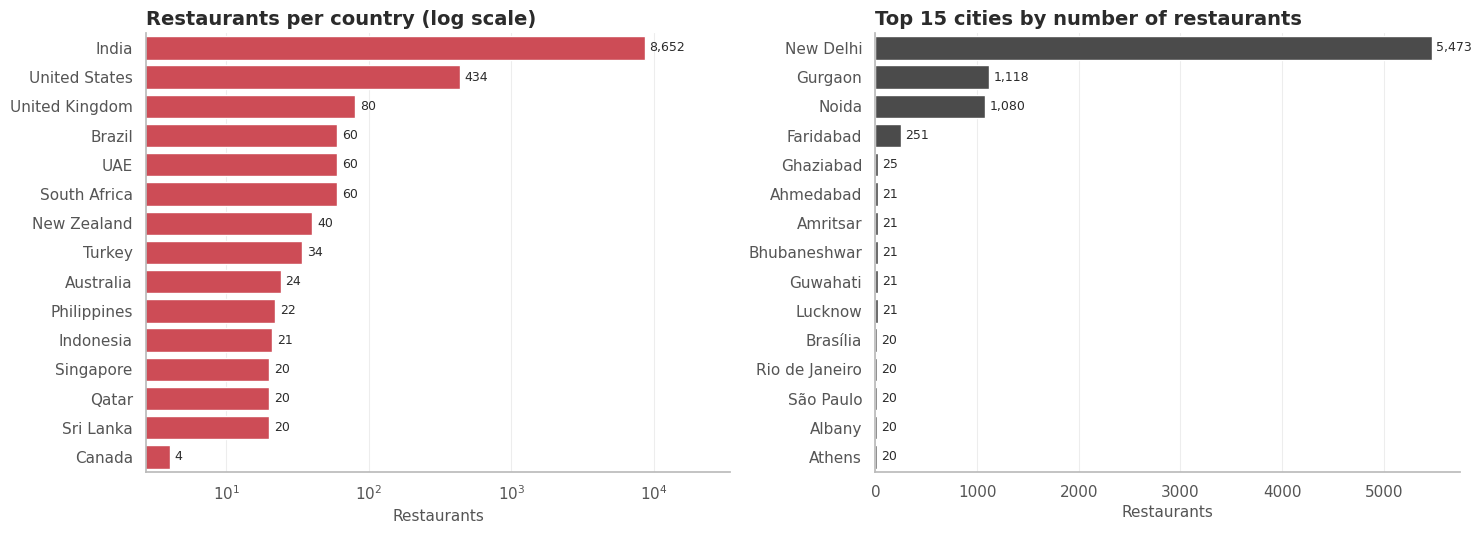

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
cc = df["country"].value_counts()
sns.barplot(x=cc.values, y=cc.index, ax=axes[0], color=RED)
axes[0].set_xscale("log"); axes[0].set_xlim(right=cc.max() * 4)
axes[0].set_title("Restaurants per country (log scale)"); axes[0].set_xlabel("Restaurants"); axes[0].set_ylabel("")
for i, v in enumerate(cc.values):
    axes[0].text(v * 1.08, i, f"{v:,}", va="center", fontsize=9)
ct = df["city"].value_counts().head(15)
sns.barplot(x=ct.values, y=ct.index, ax=axes[1], color="#4B4B4B")
axes[1].set_title("Top 15 cities by number of restaurants"); axes[1].set_xlabel("Restaurants"); axes[1].set_ylabel("")
for i, v in enumerate(ct.values):
    axes[1].text(v + 40, i, f"{v:,}", va="center", fontsize=9)
save("01_restaurants_by_country_city")
print(cc.to_string())

### 4.2 How are restaurants rated?

count    7403.00
mean        3.44
std         0.55
min         1.80
25%         3.00
50%         3.40
75%         3.80
max         4.90

Skewness: 0.23

Share of restaurants that are UNRATED:
price_tier
Budget         38.3
Moderate       12.9
Upscale         2.5
Fine dining     1.9
has_online_delivery
0    28.9
1     3.9


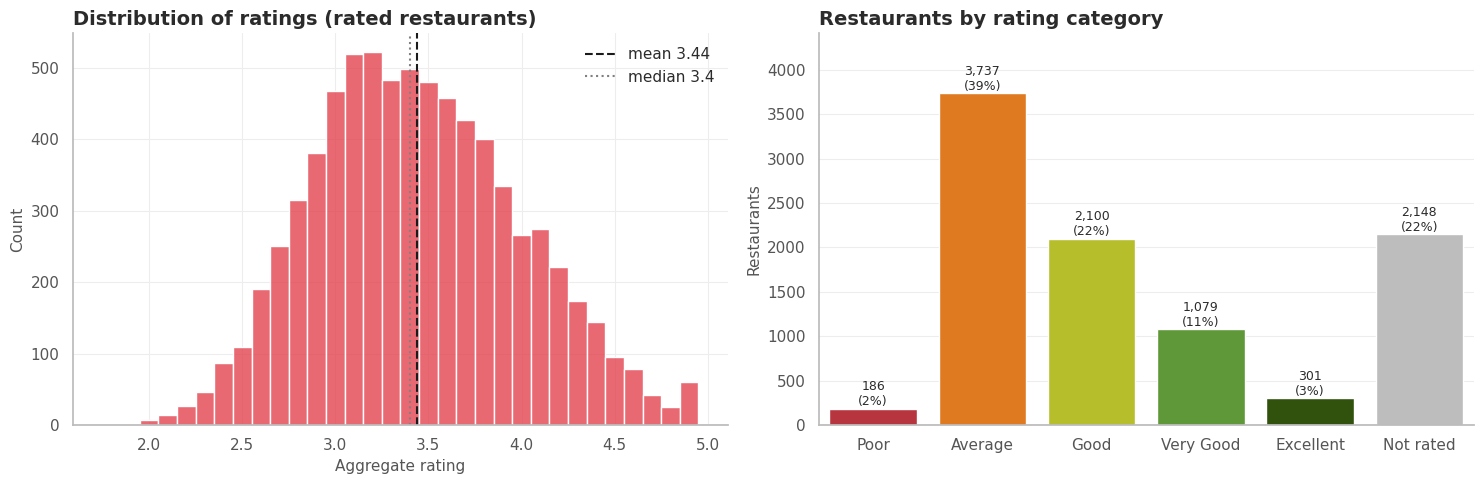

In [14]:
order = ["Poor", "Average", "Good", "Very Good", "Excellent", "Not rated"]
pal = {"Poor": "#CB202D", "Average": "#FF7800", "Good": "#CDD614", "Very Good": "#5BA829", "Excellent": "#305D02", "Not rated": "#BDBDBD"}
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(rated["rating"], bins=np.arange(1.75, 5.0, 0.1), color=RED, ax=axes[0])
axes[0].axvline(rated.rating.mean(), color="k", ls="--", label=f"mean {rated.rating.mean():.2f}")
axes[0].axvline(rated.rating.median(), color="grey", ls=":", label=f"median {rated.rating.median():.1f}")
axes[0].legend(); axes[0].set_title("Distribution of ratings (rated restaurants)"); axes[0].set_xlabel("Aggregate rating")
rt = df["rating_text"].value_counts().reindex(order)
sns.barplot(x=rt.index, y=rt.values, palette=pal, ax=axes[1])
axes[1].set_title("Restaurants by rating category"); axes[1].set_xlabel(""); axes[1].set_ylabel("Restaurants")
for i, v in enumerate(rt.values):
    axes[1].text(i, v + 40, f"{v:,}\n({v/len(df):.0%})", ha="center", fontsize=9)
axes[1].set_ylim(top=rt.max() * 1.18)
save("02_rating_distribution")
print(rated.rating.describe().round(2).to_string())
print(f"\nSkewness: {stats.skew(rated.rating):.2f}")
print("\nShare of restaurants that are UNRATED:")
print((1 - df.groupby("price_tier")["is_rated"].mean()).mul(100).round(1).reindex(["Budget", "Moderate", "Upscale", "Fine dining"]).rename("% unrated by price tier").to_string())
print((1 - df.groupby("has_online_delivery")["is_rated"].mean()).mul(100).round(1).rename("% unrated by online delivery (0/1)").to_string())

### 4.3 Votes — popularity and reliability of ratings

Spearman correlation votes vs rating: 0.68
          restaurants  mean_rating
votes                             
0-10             1075         2.98
11-50            2354         3.19
51-100           1169         3.41
101-500          2100         3.74
501-1000          409         4.08
1000+             296         4.20

Median votes: 31 | mean: 157 | max: 10,934
Restaurants with fewer than 10 votes: 32.3%

Top 10 by votes:
          restaurant_name      city  votes  rating  price_tier
                     Toit Bangalore  10934     4.8 Fine dining
                 Truffles Bangalore   9667     4.7    Moderate
         Hauz Khas Social New Delhi   7931     4.3     Upscale
                Peter Cat   Kolkata   7574     4.3     Upscale
AB's - Absolute Barbecues Bangalore   6907     4.6     Upscale
          Barbeque Nation   Kolkata   5966     4.9     Upscale
              Big Brewsky Bangalore   5705     4.5     Upscale
AB's - Absolute Barbecues Hyderabad   5434     4.9     Upscale
    

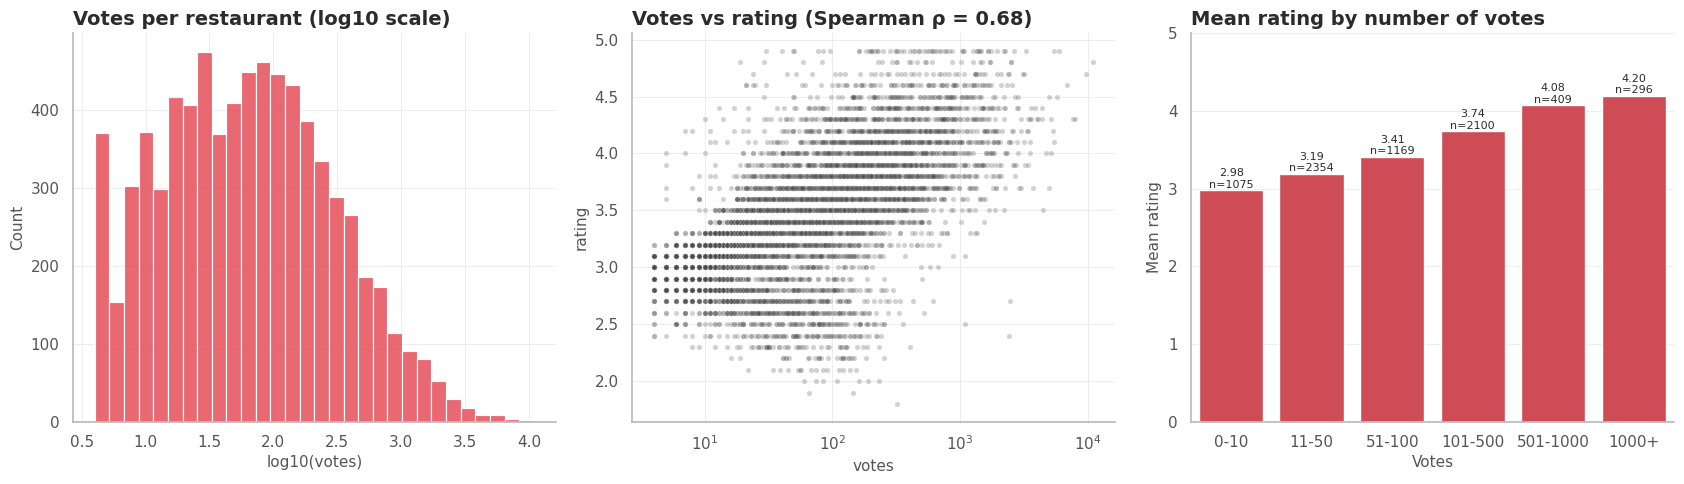

In [15]:
rho, p = stats.spearmanr(rated.votes, rated.rating)
bins = pd.cut(rated.votes, [-1, 10, 50, 100, 500, 1000, 20000], labels=["0-10", "11-50", "51-100", "101-500", "501-1000", "1000+"])
vb = rated.groupby(bins, observed=True)["rating"].agg(["count", "mean"])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.histplot(rated["log_votes"], bins=30, color=RED, ax=axes[0])
axes[0].set_title("Votes per restaurant (log10 scale)"); axes[0].set_xlabel("log10(votes)")
sns.scatterplot(data=rated, x="votes", y="rating", alpha=0.25, s=14, color="#4B4B4B", ax=axes[1])
axes[1].set_xscale("log"); axes[1].set_title(f"Votes vs rating (Spearman ρ = {rho:.2f})")
sns.barplot(x=vb.index.astype(str), y=vb["mean"].values, color=RED, ax=axes[2])
axes[2].set_ylim(0, 5); axes[2].set_title("Mean rating by number of votes"); axes[2].set_xlabel("Votes"); axes[2].set_ylabel("Mean rating")
for i, (m, n) in enumerate(zip(vb["mean"], vb["count"])):
    axes[2].text(i, m + 0.03, f"{m:.2f}\nn={n}", ha="center", fontsize=8)
save("03_votes")
print(f"Spearman correlation votes vs rating: {rho:.2f}")
print(vb.round(2).rename(columns={"count": "restaurants", "mean": "mean_rating"}).to_string())
print(f"\nMedian votes: {df.votes.median():.0f} | mean: {df.votes.mean():.0f} | max: {df.votes.max():,}")
print(f"Restaurants with fewer than 10 votes: {(df.votes < 10).mean():.1%}")
print("\nTop 10 by votes:")
print(df.nlargest(10, "votes")[["restaurant_name", "city", "votes", "rating", "price_tier"]].to_string(index=False))

### 4.4 Price: how cost relates to rating

             count  mean  median
price_tier                      
Budget        2744  3.24     3.2
Moderate      2711  3.38     3.4
Upscale       1373  3.78     3.8
Fine dining    575  3.89     3.9

India only: Spearman(cost per person, rating) = 0.33  (n = 6,504)
Kruskal-Wallis across price tiers: H = 1326.1, p = 3.25e-287


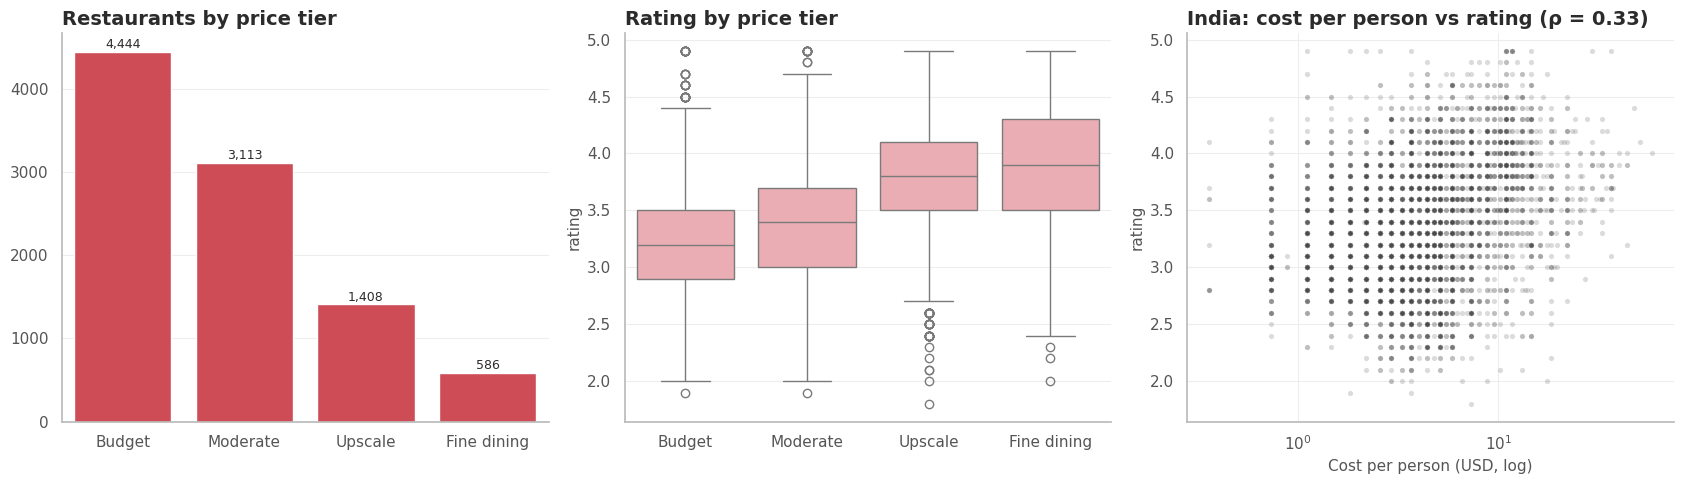

In [16]:
tier_order = ["Budget", "Moderate", "Upscale", "Fine dining"]
india = rated[(rated.country == "India") & rated.cost_per_person_usd.notna()]
rho_in, _ = stats.spearmanr(india.cost_per_person_usd, india.rating)
groups = [g["rating"].values for _, g in rated.groupby("price_range")]
kw = stats.kruskal(*groups)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
pr = df["price_tier"].value_counts().reindex(tier_order)
sns.barplot(x=pr.index, y=pr.values, color=RED, ax=axes[0]); axes[0].set_title("Restaurants by price tier"); axes[0].set_xlabel("")
for i, v in enumerate(pr.values):
    axes[0].text(i, v + 40, f"{v:,}", ha="center", fontsize=9)
sns.boxplot(data=rated, x="price_tier", y="rating", order=tier_order, color="#F4A3AB", ax=axes[1])
axes[1].set_title("Rating by price tier"); axes[1].set_xlabel("")
sns.scatterplot(data=india, x="cost_per_person_usd", y="rating", alpha=0.2, s=14, color="#4B4B4B", ax=axes[2])
axes[2].set_xscale("log"); axes[2].set_title(f"India: cost per person vs rating (ρ = {rho_in:.2f})"); axes[2].set_xlabel("Cost per person (USD, log)")
save("04_price_vs_rating")
print(rated.groupby("price_tier")["rating"].agg(["count", "mean", "median"]).reindex(tier_order).round(2).to_string())
print(f"\nIndia only: Spearman(cost per person, rating) = {rho_in:.2f}  (n = {len(india):,})")
print(f"Kruskal-Wallis across price tiers: H = {kw.statistic:.1f}, p = {kw.pvalue:.2e}")

### 4.5 Table booking & online delivery
Online delivery is only recorded for **India and the UAE** (0 % everywhere else) and table booking is almost only recorded in India, so mixing countries would confound the comparison.
This section therefore uses **India only**.

Countries with any online-delivery restaurant: ['India', 'UAE']
Countries with any table-booking restaurant  : ['India', 'Philippines', 'Qatar', 'South Africa', 'UAE', 'United Kingdom']

has_table_booking     : mean rating 3.55 (yes, n=1,064) vs 3.31 (no, n=5,449)   Mann-Whitney p = 6.8e-50
has_online_delivery   : mean rating 3.37 (yes, n=2,327) vs 3.34 (no, n=4,186)   Mann-Whitney p = 5.9e-07

India: table booking 12.8% | online delivery 28.0% | delivering now 0.36% (all countries)

Within each price tier — booking (controls for price):
             mean no booking  mean with booking  n no booking  n with booking
price_tier                                                                   
Budget                  3.20               3.70          2595               1
Moderate                3.31               3.36          2246             216
Upscale                 3.79               3.59           474             604
Fine dining             3.94               3.62           134     

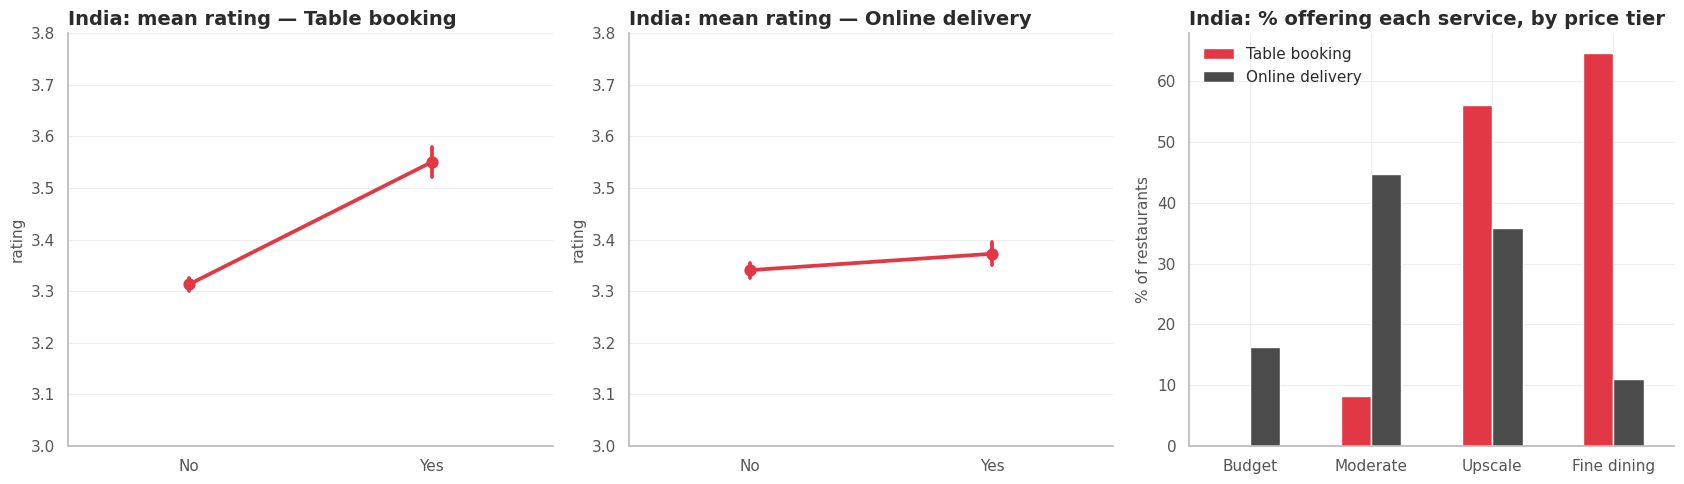

In [17]:
ind_all = df[df.country == "India"]
ind = rated[rated.country == "India"]
print("Countries with any online-delivery restaurant:", sorted(df.loc[df.has_online_delivery == 1, "country"].unique()))
print("Countries with any table-booking restaurant  :", sorted(df.loc[df.has_table_booking == 1, "country"].unique()))
print()

def mwu(col):
    a, b = ind.loc[ind[col] == 1, "rating"], ind.loc[ind[col] == 0, "rating"]
    p = stats.mannwhitneyu(a, b, alternative="two-sided").pvalue
    print(f"{col:22s}: mean rating {a.mean():.2f} (yes, n={len(a):,}) vs {b.mean():.2f} (no, n={len(b):,})   Mann-Whitney p = {p:.1e}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col, title in zip(axes[:2], ["has_table_booking", "has_online_delivery"], ["Table booking", "Online delivery"]):
    sns.pointplot(data=ind, x=col, y="rating", errorbar=("ci", 95), color=RED, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No", "Yes"]); ax.set_ylim(3.0, 3.8)
    ax.set_title(f"India: mean rating — {title}"); ax.set_xlabel("")
svc = ind_all.groupby("price_tier")[["has_table_booking", "has_online_delivery"]].mean().mul(100).reindex(tier_order)
svc.columns = ["Table booking", "Online delivery"]
svc.plot.bar(ax=axes[2], color=[RED, "#4B4B4B"], rot=0)
axes[2].set_title("India: % offering each service, by price tier"); axes[2].set_xlabel(""); axes[2].set_ylabel("% of restaurants")
save("05_services")
mwu("has_table_booking"); mwu("has_online_delivery")
print(f"\nIndia: table booking {ind_all.has_table_booking.mean():.1%} | online delivery {ind_all.has_online_delivery.mean():.1%} | delivering now {df.is_delivering_now.mean():.2%} (all countries)")
for col, lab in [("has_table_booking", "booking"), ("has_online_delivery", "delivery")]:
    m = ind.pivot_table(index="price_tier", columns=col, values="rating", aggfunc=["mean", "size"]).reindex(tier_order)
    m.columns = [f"{'mean' if a == 'mean' else 'n'} {'no' if b == 0 else 'with'} {lab}" for a, b in m.columns]
    print(f"\nWithin each price tier — {lab} (controls for price):")
    print(m.round(2).to_string())

### 4.6 Cuisines

India only — highest-rated cuisines (>= 30 rated):
                 n  mean_rating  median_cost_pp_usd
cuisine                                            
Mediterranean   89         3.98               10.95
European       117         3.91               12.41
Asian          181         3.85               10.95
Mexican        124         3.83                7.30
Seafood         78         3.78               10.22
Italian        644         3.71                7.30
Continental    687         3.70                8.76
Thai           200         3.69                8.03

India only — lowest-rated cuisines (>= 30 rated):
                 n  mean_rating  median_cost_pp_usd
cuisine                                            
Mughlai        791         3.27                4.74
Street Food    395         3.27                1.82
Fast Food     1540         3.25                3.28
Pizza          260         3.24                5.11
South Indian   480         3.23                3.28
Salad         

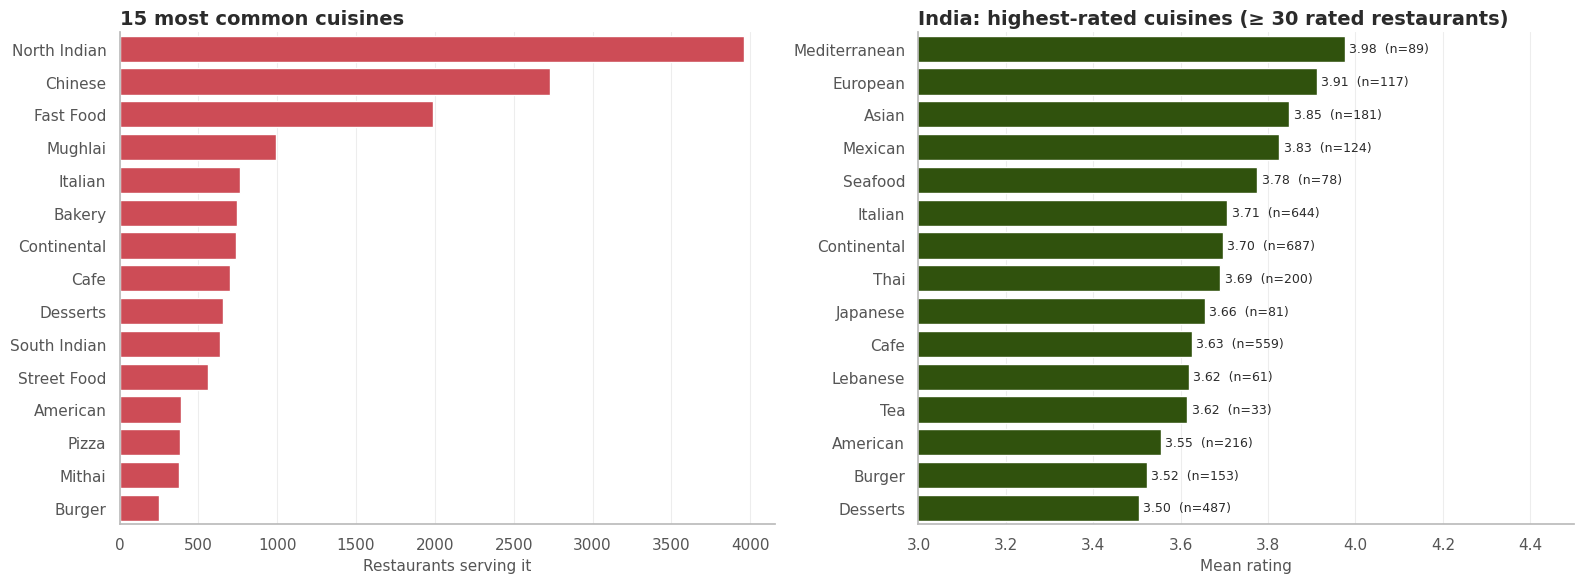

In [18]:
cx = df.explode("cuisine_list").rename(columns={"cuisine_list": "cuisine"})
cx = cx[cx.cuisine != "Unknown"]
top_c = cx["cuisine"].value_counts().head(15)
cstat = (cx[cx.is_rated & (cx.country == "India")].groupby("cuisine")
         .agg(n=("rating", "size"), mean_rating=("rating", "mean"), median_cost_pp_usd=("cost_per_person_usd", "median"))
         .query("n >= 30").sort_values("mean_rating", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=top_c.values, y=top_c.index, color=RED, ax=axes[0])
axes[0].set_title("15 most common cuisines"); axes[0].set_xlabel("Restaurants serving it"); axes[0].set_ylabel("")
best = cstat.head(15)
sns.barplot(x=best["mean_rating"], y=best.index, color="#305D02", ax=axes[1])
axes[1].set_xlim(3.0, 4.5); axes[1].set_title("India: highest-rated cuisines (≥ 30 rated restaurants)"); axes[1].set_xlabel("Mean rating"); axes[1].set_ylabel("")
for i, (m, n) in enumerate(zip(best["mean_rating"], best["n"])):
    axes[1].text(m + 0.01, i, f"{m:.2f}  (n={n})", va="center", fontsize=9)
save("06_cuisines")
print("India only — highest-rated cuisines (>= 30 rated):")
print(cstat.head(8).round(2).to_string())
print("\nIndia only — lowest-rated cuisines (>= 30 rated):")
print(cstat.tail(8).round(2).to_string())
print(f"\nDistinct cuisines: {cx.cuisine.nunique()} | restaurants listing a single cuisine: {(df.n_cuisines == 1).mean():.1%}")
print(f"Top-3 primary cuisines: {df.primary_cuisine.value_counts().head(3).to_dict()}")

### 4.7 Does offering more cuisines help?

                   n  mean_rating  median_cost
n_cuisines_cap                                
1               2224         3.40         3.28
2               2739         3.39         4.01
3               1603         3.49         5.11
4                555         3.58         5.84
5                273         3.66         7.30


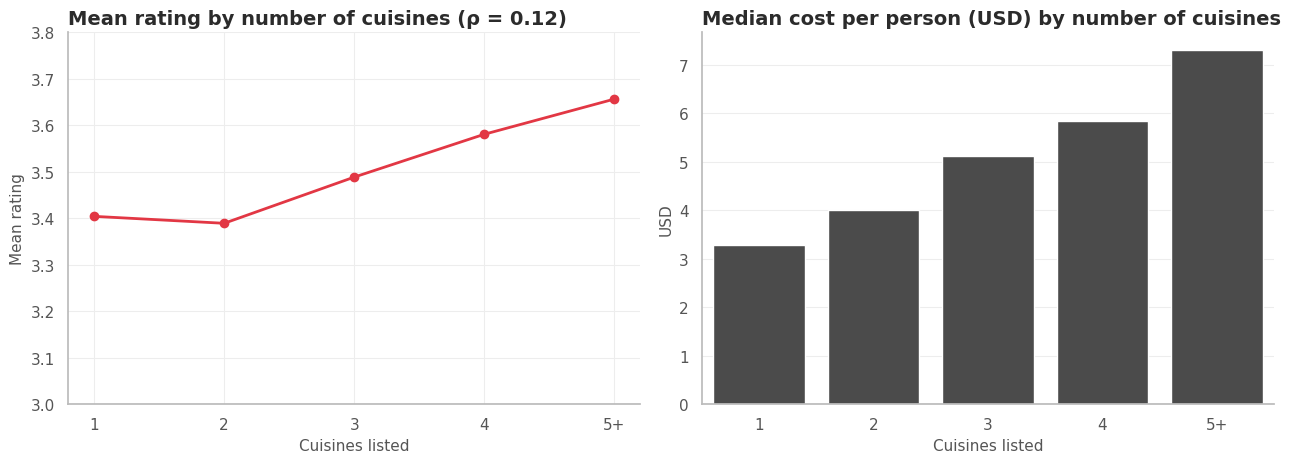

In [19]:
df["n_cuisines_cap"] = df["n_cuisines"].clip(upper=5)
rated = df[df.is_rated].copy()
ncu = rated[rated.n_cuisines > 0].groupby("n_cuisines_cap").agg(n=("rating", "size"), mean_rating=("rating", "mean"), median_cost=("cost_per_person_usd", "median"))
rho_n, _ = stats.spearmanr(rated.loc[rated.n_cuisines > 0, "n_cuisines"], rated.loc[rated.n_cuisines > 0, "rating"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(["1", "2", "3", "4", "5+"], ncu["mean_rating"].values, marker="o", color=RED, lw=2)
axes[0].set_ylim(3.0, 3.8); axes[0].set_title(f"Mean rating by number of cuisines (ρ = {rho_n:.2f})"); axes[0].set_xlabel("Cuisines listed"); axes[0].set_ylabel("Mean rating")
sns.barplot(x=ncu.index.astype(str).str.replace("5", "5+"), y=ncu["median_cost"].values, color="#4B4B4B", ax=axes[1])
axes[1].set_title("Median cost per person (USD) by number of cuisines"); axes[1].set_xlabel("Cuisines listed"); axes[1].set_ylabel("USD")
save("07_n_cuisines")
print(ncu.round(2).to_string())

### 4.8 Cities and localities

Outside Delhi NCR the dataset holds a median of 20 restaurants per city (max 21), so city averages there rest on ~20 restaurants each.
Cities with >= 15 rated restaurants: 80 (the rest of the dataset is spread thinly over ~61 other cities)

Top 6 cities by mean rating:
       country           city  n  mean_rating
United Kingdom         London 20         4.54
        Brazil Rio de Janeiro 19         4.49
 United States        Orlando 20         4.47
 United States      Tampa Bay 20         4.41
 United States Rest of Hawaii 20         4.41
         India      Bangalore 20         4.38

Bottom 6:
country       city    n  mean_rating
  India  Ghaziabad   23         3.10
  India  Faridabad  151         3.10
  India      Noida  696         3.16
  India  New Delhi 4048         3.30
  India    Gurgaon  890         3.33
  India Aurangabad   20         3.38

Busiest India localities:
                   n  mean_rating
locality                         
Connaught Place  122         3.78
Rajouri G

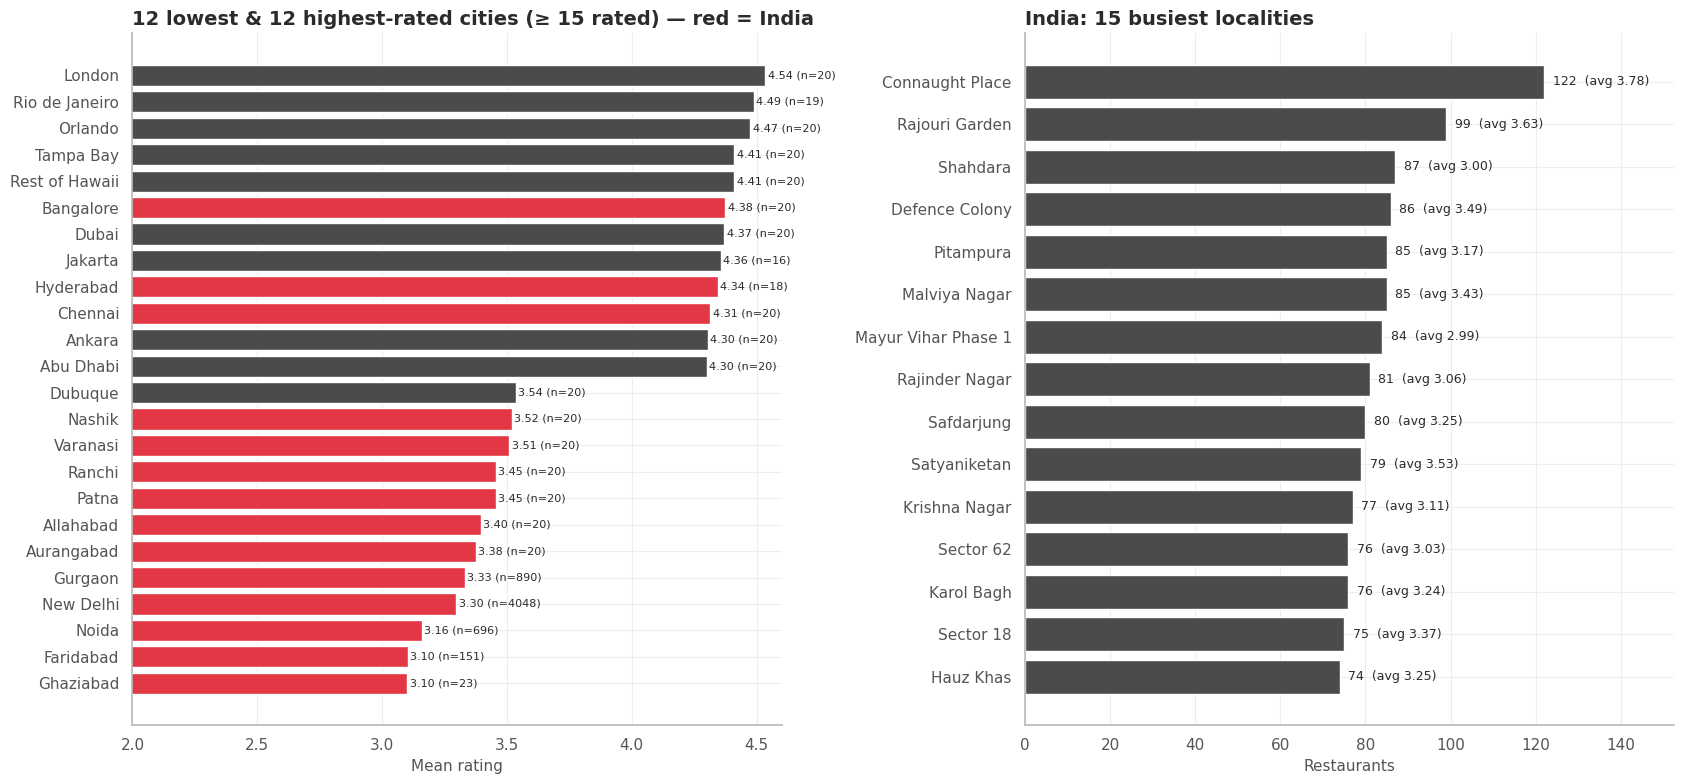

In [20]:
cs = rated.groupby(["country", "city"]).agg(n=("rating", "size"), mean_rating=("rating", "mean")).query("n >= 15").reset_index().sort_values("mean_rating")
loc = df[df.country == "India"].groupby("locality").agg(n=("restaurant_id", "size"), mean_rating=("rating", "mean")).sort_values("n", ascending=False).head(15)

cs_plot = pd.concat([cs.head(12), cs.tail(12)])
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
colors = [RED if c == "India" else "#4B4B4B" for c in cs_plot.country]
axes[0].barh(cs_plot.city, cs_plot.mean_rating, color=colors)
for i, (m, n) in enumerate(zip(cs_plot.mean_rating, cs_plot.n)):
    axes[0].text(m + 0.01, i, f"{m:.2f} (n={n})", va="center", fontsize=8)
axes[0].set_xlim(2.0, 4.6); axes[0].set_title("12 lowest & 12 highest-rated cities (≥ 15 rated) — red = India"); axes[0].set_xlabel("Mean rating")
axes[1].barh(loc.index[::-1], loc.n[::-1], color="#4B4B4B")
for i, (n, m) in enumerate(zip(loc.n[::-1], loc.mean_rating[::-1])):
    axes[1].text(n + 2, i, f"{n}  (avg {m:.2f})", va="center", fontsize=9)
axes[1].set_xlim(right=loc.n.max() * 1.25); axes[1].set_title("India: 15 busiest localities"); axes[1].set_xlabel("Restaurants")
save("08_cities_localities")
per_city = df[~df.delhi_ncr].groupby("city").size()
print(f"Outside Delhi NCR the dataset holds a median of {per_city.median():.0f} restaurants per city (max {per_city.max()}), so city averages there rest on ~20 restaurants each.")
print(f"Cities with >= 15 rated restaurants: {len(cs)} (the rest of the dataset is spread thinly over ~{df.city.nunique() - len(cs)} other cities)")
print("\nTop 6 cities by mean rating:"); print(cs.tail(6).iloc[::-1].round(2).to_string(index=False))
print("\nBottom 6:"); print(cs.head(6).round(2).to_string(index=False))
print("\nBusiest India localities:"); print(loc.round(2).head(6).to_string())

### 4.9 Country comparison

                restaurants  pct_rated  online_delivery  table_booking  median_cost_pp_usd  mean_rating
country                                                                                                
India                  8652       75.0             28.0           13.0                3.28         3.35
United States           434       99.0              0.0            0.0               12.50         4.03
United Kingdom           80       99.0              0.0           15.0               26.60         4.14
UAE                      60      100.0             47.0           30.0               19.72         4.23
South Africa             60      100.0              0.0            3.0               12.75         4.21
Brazil                   60       92.0              0.0            0.0               13.50         4.11
New Zealand              40      100.0              0.0            0.0               20.40         4.26
Turkey                   34      100.0              0.0         

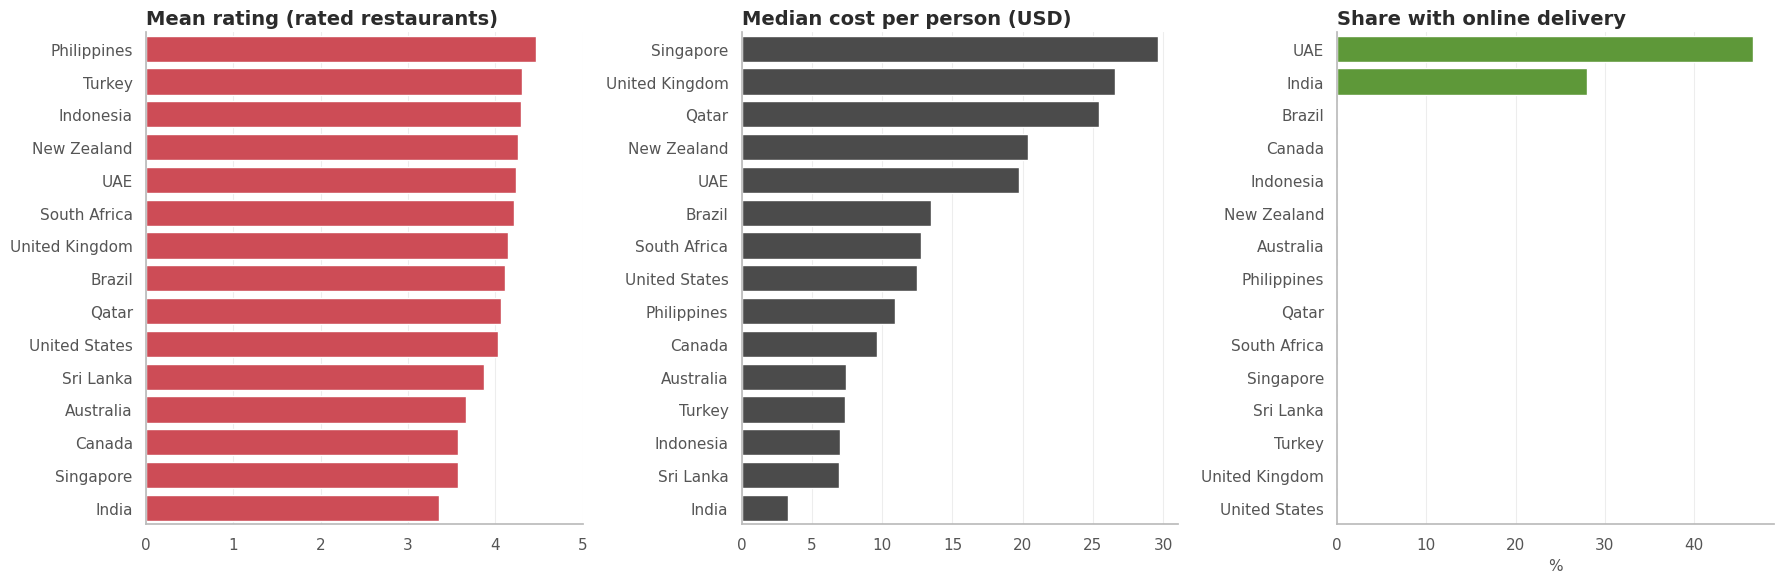

In [21]:
ctry = (df.groupby("country").agg(restaurants=("restaurant_id", "size"), pct_rated=("is_rated", "mean"),
                                  online_delivery=("has_online_delivery", "mean"), table_booking=("has_table_booking", "mean"),
                                  median_cost_pp_usd=("cost_per_person_usd", "median"))
        .join(rated.groupby("country")["rating"].agg(mean_rating="mean")))
show = ctry.copy()
for c in ["pct_rated", "online_delivery", "table_booking"]:
    show[c] = (show[c] * 100).round(0)
print(show.round(2).sort_values("restaurants", ascending=False).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, title, colr in zip(axes, ["mean_rating", "median_cost_pp_usd", "online_delivery"],
                                ["Mean rating (rated restaurants)", "Median cost per person (USD)", "Share with online delivery"],
                                [RED, "#4B4B4B", "#5BA829"]):
    s = ctry[col].sort_values(ascending=False)
    sns.barplot(x=s.values * (100 if col == "online_delivery" else 1), y=s.index, color=colr, ax=ax)
    ax.set_title(title); ax.set_ylabel(""); ax.set_xlabel("%" if col == "online_delivery" else "")
axes[0].set_xlim(0, 5)
save("09_country_comparison")

### 4.10 Geography

Delhi NCR points plotted: 7,546 of 9,051 valid points


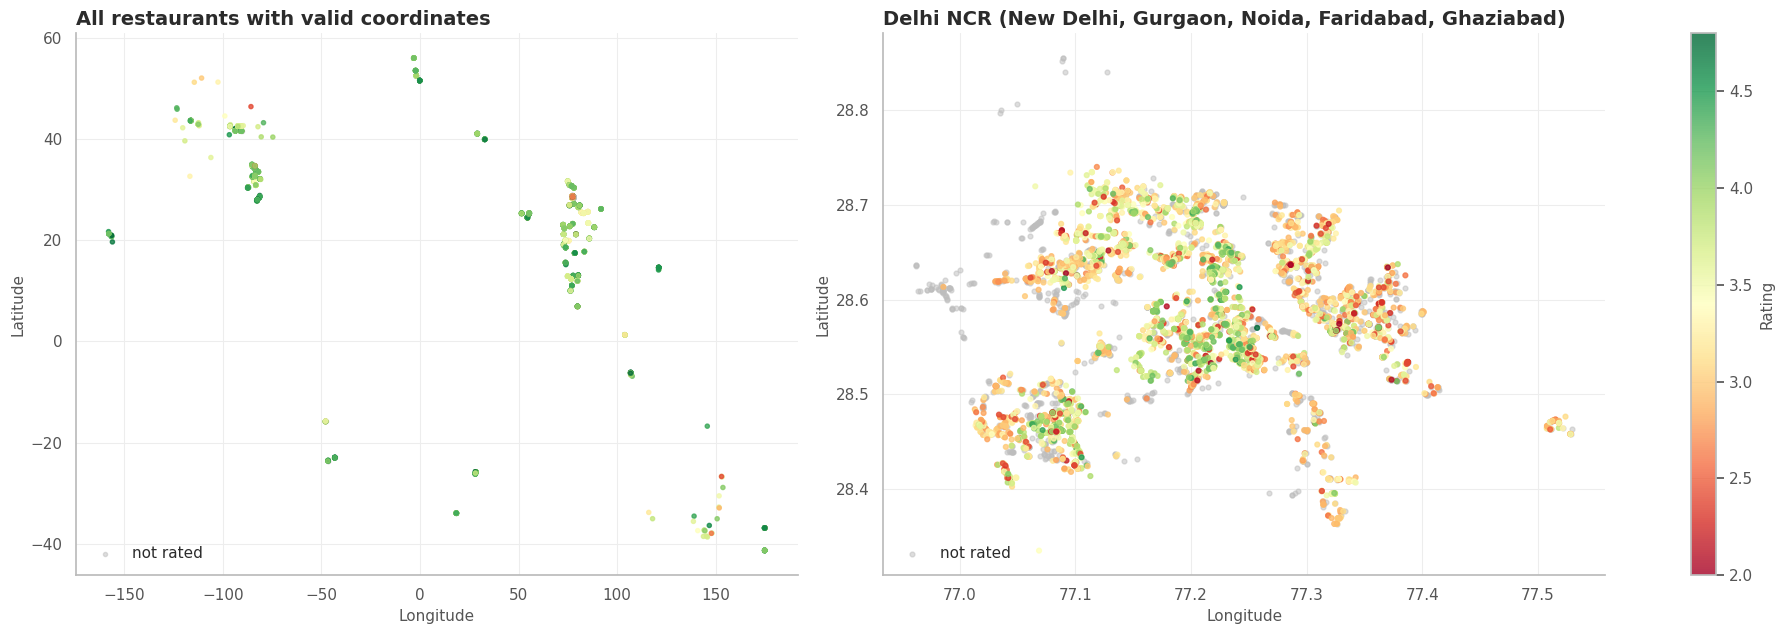

In [22]:
g = df[df.coords_valid]
ncr = g[g.delhi_ncr & g.latitude.between(28.3, 28.95) & g.longitude.between(76.8, 77.6)]
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), gridspec_kw={"width_ratios": [1, 1, 0.035]})
for ax, d, title, s in [(axes[0], g, "All restaurants with valid coordinates", 9), (axes[1], ncr, "Delhi NCR (New Delhi, Gurgaon, Noida, Faridabad, Ghaziabad)", 12)]:
    u = d[~d.is_rated]; r = d[d.is_rated]
    ax.scatter(u.longitude, u.latitude, s=s, c="#BDBDBD", alpha=0.5, label="not rated")
    sc = ax.scatter(r.longitude, r.latitude, s=s, c=r.rating, cmap="RdYlGn", vmin=2, vmax=4.8, alpha=0.8)
    ax.set_title(title); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.legend(loc="lower left")
fig.colorbar(sc, cax=axes[2], label="Rating")
save("10_geography")
print(f"Delhi NCR points plotted: {len(ncr):,} of {len(g):,} valid points")

### 4.11 Correlations

log_votes              0.68
cost_pp_usd            0.45
price_range            0.40
has_table_booking      0.13
n_cuisines             0.12
has_online_delivery   -0.04


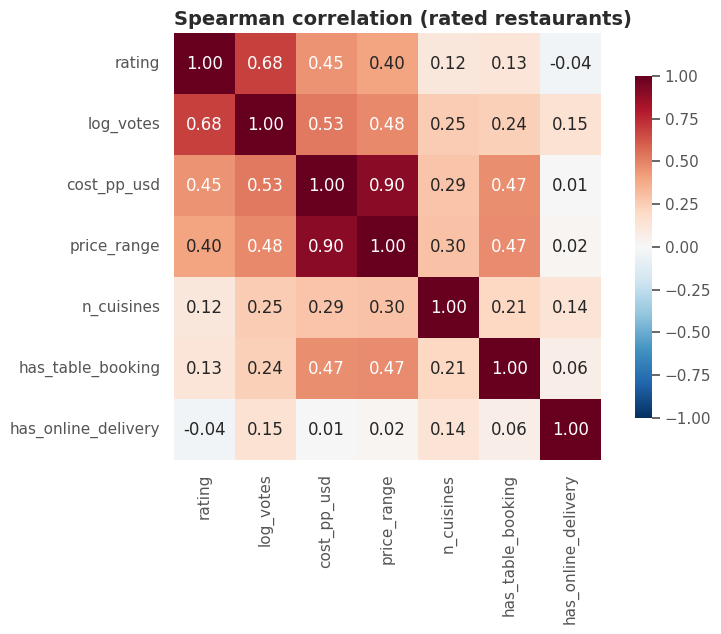

In [23]:
num = rated.assign(cost_pp_usd=rated.cost_per_person_usd)[["rating", "log_votes", "cost_pp_usd", "price_range", "n_cuisines", "has_table_booking", "has_online_delivery"]].dropna()
corr = num.corr(method="spearman")
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Spearman correlation (rated restaurants)")
save("11_correlation")
print(corr["rating"].drop("rating").sort_values(ascending=False).round(2).to_string())

### 4.12 Restaurant chains

                  outlets  mean_rating  total_votes
restaurant_name                                    
Domino's Pizza         74         2.93         6637
Cafe Coffee Day        67         3.00         2412
Subway                 61         3.00         6122
McDonald's             47         3.41         5290
Green Chick Chop       44         3.10          953
Keventers              29         3.37         1253
Pizza Hut              29         3.43         4961
Barbeque Nation        26         4.35        28142
Giani                  24         3.25          849
Barista                21         3.22          815
Sagar Ratna            19         2.96         4038
Dunkin' Donuts         19         3.63         5971
Pind Balluchi          18         2.92         5579
Giani's                18         3.40         1144
Starbucks              18         3.81         7139


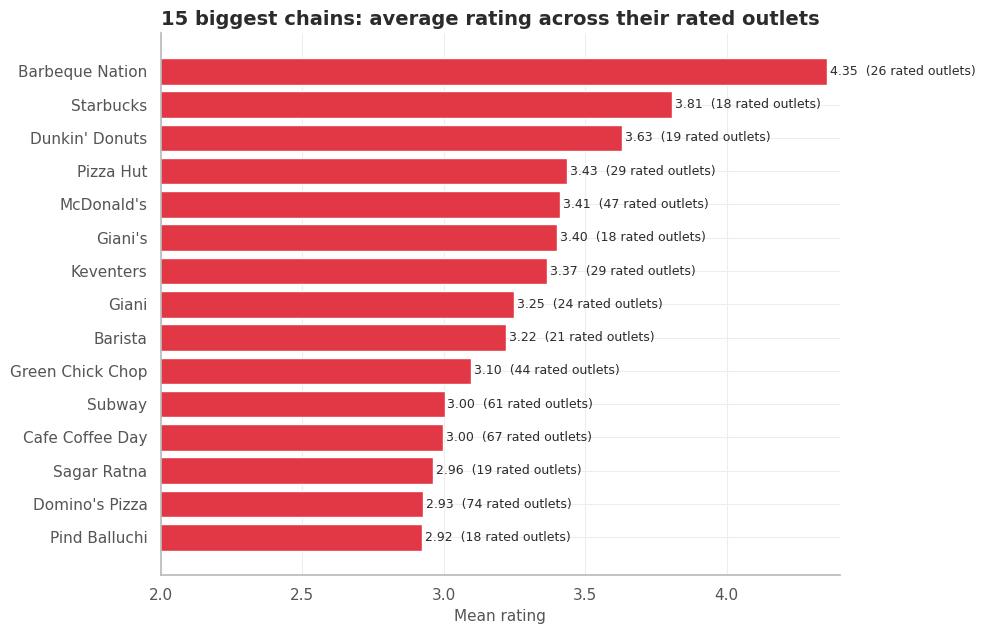

In [24]:
ch = (rated.groupby("restaurant_name").agg(outlets=("restaurant_id", "size"), mean_rating=("rating", "mean"), total_votes=("votes", "sum"))
      .query("outlets >= 8").sort_values("outlets", ascending=False).head(15).sort_values("mean_rating"))
plt.figure(figsize=(10, 6.5))
plt.barh(ch.index, ch.mean_rating, color=RED)
for i, (m, n) in enumerate(zip(ch.mean_rating, ch.outlets)):
    plt.text(m + 0.01, i, f"{m:.2f}  ({n} rated outlets)", va="center", fontsize=9)
plt.xlim(2.0, 4.4); plt.xlabel("Mean rating"); plt.title("15 biggest chains: average rating across their rated outlets")
save("12_chains")
print(ch.sort_values("outlets", ascending=False).round(2).to_string())

## 5. Key insights

### Data quality — what cleaning changed
- The table went from 9,551 × 21 to 9,551 × 29. **No rows were dropped**: no duplicates were found, and impossible values were set to missing instead of deleting the restaurant.
- About 84 % of the 428 text cells damaged by encoding errors (`�`) were restored (Café, São Paulo, Brasília, İstanbul …); the rest had the junk characters removed because the original bytes are gone.
- **22.5 % of restaurants (2,148) have rating 0, which means "not rated"**. Left as 0, it drags the average rating down to 2.67 instead of 3.44 for rated places. 1,054 of them still carry votes — an inconsistency in the source.
- Also fixed: 18 zero costs, 500 unusable coordinates (497 in India), 9 missing cuisines, 22 Philippine rows labelled *Botswana Pula*, and costs converted to one approximate USD scale so countries can be compared.

### What the data says
1. **Coverage is very uneven.** India is 90.6 % of the rows and Delhi NCR alone 83.2 %. Outside Delhi NCR the file holds only about 20 restaurants per city, so city and country comparisons compare *samples*, not whole markets.
2. **Ratings are bell-shaped**: mean 3.44, median 3.4, range 1.8–4.9. Most restaurants are "Average" (3,737) or "Good" (2,100); only 301 are "Excellent" (4.5+) and 186 "Poor".
3. **Popularity and rating move together** (Spearman ρ = 0.68). Mean rating climbs from 2.98 for restaurants with ≤ 10 votes to 4.20 for 1,000+ votes. 32 % of restaurants have fewer than 10 votes, so many ratings are noisy.
4. **Unrated restaurants are mostly cheap ones**: 38 % of budget restaurants are unrated versus about 2 % of upscale/fine-dining ones.
5. **Higher price tier → higher rating**: 3.24 (budget), 3.38, 3.78, 3.89 (fine dining). In India, cost per person and rating correlate at ρ = 0.33.
6. **Table booking looks like a rating boost but mostly is not.** In India, restaurants with booking average 3.55 vs 3.31 without, yet inside the Upscale and Fine-dining tiers booking restaurants rate *lower* (3.59 vs 3.79 and 3.62 vs 3.94). Booking is simply more common at expensive places (about 65 % of fine dining vs almost none of budget). **Online delivery has no consistent effect** (3.37 vs 3.34 overall; mixed by tier).
7. **Cuisines.** North Indian is the most common primary cuisine (2,992), then Chinese and Fast Food. In India the best-rated cuisines are Mediterranean (3.98), European, Asian and Mexican (3.8–3.9); the lowest are Raw Meats, Mithai, Salad, South Indian, Pizza and Fast Food (about 3.1–3.25). The better-rated cuisines are also the pricier ones (median ≈ $7–12 per person vs ≈ $2–5), which again points to price.
8. **More cuisines listed → slightly higher rating** (3.40 for one cuisine, 3.66 for five or more), but cost rises too and the correlation is weak (ρ ≈ 0.12).
9. **Cities and localities.** Among cities with enough data, Ghaziabad (3.10), Faridabad (3.10), Noida (3.16), New Delhi (3.30) and Gurgaon (3.33) rate lowest; London (4.54), Rio (4.49), Orlando (4.47) and Bangalore (4.38) top the list, but each rests on ~20 restaurants. Connaught Place is the busiest locality (122 restaurants, avg 3.78), while busy Shahdara and Mayur Vihar Phase 1 average about 3.0.
10. **Countries.** India averages 3.35 versus 3.6–4.5 elsewhere, but the foreign samples are small (≤ 434 each, mostly ~20–80) and almost entirely rated (India: 75 %), so they are probably better-known places — this is **not** a quality ranking. Median cost per person is about $3 in India, $27 in the UK and $30 in Singapore. Online delivery is recorded only for India (28 %) and the UAE (47 %).
11. **Chains.** The three biggest chains rate well below the 3.44 average: Domino's 2.93, Cafe Coffee Day 3.00, Subway 3.00. McDonald's (3.41) and Pizza Hut (3.43) sit near it, while Starbucks (3.81) and Barbeque Nation (4.35, 26 rated outlets) stand out.
12. **Correlation with rating** (Spearman): votes 0.68, cost per person 0.45, price range 0.40, table booking 0.13, number of cuisines 0.12, online delivery −0.04.

### Caveats
- USD figures use fixed, approximate 2018 exchange rates — good for comparing countries roughly, not for exact prices.
- Encoding repairs are best guesses from context; ~70 cells could not be restored.
- The sample is not random (see point 1); the relationships above are associations, not causes, and votes and ratings can reinforce each other.

### Where to go next
- Deep-dive Delhi NCR only (83 % of the data, the one area with enough restaurants per locality).
- Build a rating model on the cleaned file (`Zomato_cleaned.csv`) using cost, votes, cuisines, services and location.